# IoT MQTT Authentication — Decision Tree Pipeline

Companion to `logistic_regression_pipeline.ipynb`. The data loading, cleaning and
train/test split are **identical**, so the two models are directly comparable; what
changes is the learner and the analysis it invites:

* a Decision Tree is **non-linear** — it can express `token_age > X AND identity_mismatch = 1`
  style conditions that a linear model can only approximate;
* it is **scale-invariant**, so no `StandardScaler` is needed;
* it **overfits by default**, so this notebook spends a section on complexity
  control (depth validation curve + cost-complexity pruning);
* it is **directly readable** — Section 7 prints the actual decision rules, which is
  the main practical argument for a tree in an intrusion-detection setting.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_val_score, validation_curve,
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 130)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## 1. Data Loading

Load the per-session feature table produced by the simulator (same file as the
Logistic Regression notebook).

In [2]:
def find_features_csv():
    names = ["iot_auth_ml_features.csv", "iot_auth_dataset_features.csv"]
    bases = [Path.cwd(), *Path.cwd().parents]
    for base in bases:
        for sub in ["simulator/data/output", "IoT_auth_simulator/simulator/data/output"]:
            for n in names:
                p = base / sub / n
                if p.exists():
                    return p
    raise FileNotFoundError("Could not locate a *_features.csv under simulator/data/output/")

DATA_PATH = find_features_csv()
df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH)
print("Shape :", df.shape)
df.head(3)

Loaded: C:\Users\lamia\Desktop\simulator_bis\PFE_simulator\IoT_auth_simulator\simulator\data\output\iot_auth_ml_features.csv
Shape : (3100, 109)


,scenario_id,session_id,device_id,gateway_id,claimed_device_id,source_ip,registered_device,source_connection_count,battery_level,tcp_flags,connection_duration,tcp_rtt,packet_rate,inter_arrival_time,frame_length,tcp_segment_len,pairing_result,pairing_latency_ms,mqtt_msg_type,connect_flags,clean_session,username_present,password_length,keep_alive,mqtt_version,connack_code,auth_result,auth_latency_ms,failed_auth_count,requested_topic,topic_length,operation,authorization_result,topic_scope_violation,retain_flag,message_id,duplicate_flag,payload_length,payload_hash,qos_level,message_rate,byte_rate,trust_score,re_auth_required,session_present,source_ip_change,replay_window_violation,s1_latency_ms,s2_latency_ms,s3_latency_ms,s4_latency_ms,s5_latency_ms,s6_latency_ms,session_duration_s,mean_delay_s,max_delay_s,min_delay_s,n_events,n_discovery,n_gateway_advertisement,n_pairing_request,n_pairing_response,n_enrollment_request,n_enrollment_confirmed,n_registration_request,n_registration_confirmed,n_authentication_request,n_challenge_sent,n_nonce_received,n_response_sent,n_authentication_success,n_authentication_failure,n_token_issued,n_token_presented,n_token_validated,n_token_rejected,n_renewal_request,n_token_expired,n_session_opened,n_session_closed,n_access_request,n_access_granted,n_access_denied,n_retry,n_timeout,n_disconnect,visited_states,reached_session_open,reached_access_granted,reached_authenticated,n_failures,n_retries,failure_rate,n_token_reuses,n_nonce_reuses,identity_mismatch,n_state_jumps,is_anomaly,attack_type,attack_phase,severity,token_age_at_replay,nonce_age_at_reuse,timestamp_delta_s,duplicate_session_count,identity_claim_mismatch,token_device_mismatch,unauthorized_access_attempt,steps_before_access
0,adaa4614-7cfb-4d92-a48d-40f1873c205a,b49a5e1d-a25e-40d1-9fc7-df1153c59b83,c65a1b9d-d3b2-4b66-84ef-df70b1c8d200,6727f600,victim-807e3635,10.0.1.194,0,6,49.1,"SYN,ACK",837.99,34.13,1.952,512.30,139,442,1,223.63,PUBLISH,0,0,0,0,120,5,pending,0,0.00,0,iot/c65a1b9d/telemetry,22,publish,0,0,0,62086,0,507,72cae37a12c268fe6049b9fb6a017259e0d2dc0e67813d...,2,0.211,106.98,0.300,0,0,0,0,0.0,0.00,0.00,0.00,0.00,0.0,0.8380,0.1197,0.2236,0.0487,7,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,6,0,0,1,1,0,0.1429,0,0,1,1,1,identity_token_mismatch,session_opened,high,0.0,0.0,0.0,0,1,1,0,0
1,6ac08da2-5a77-4d3a-88ac-4bb963ab6dd3,033e3fce-04e8-4cc7-b944-4ee69a00d935,7c996c3f-9cb4-45e1-8865-d189fd910b31,088e9971,7c996c3f-9cb4-45e1-8865-d189fd910b31,10.0.1.187,1,9,98.5,"SYN,ACK,PSH",20405.25,13.78,45.757,21.85,242,370,1,42.39,DISCONNECT,0,0,0,0,300,5,success,1,30.69,0,iot/7c996c3f/telemetry,22,pub_sub,1,0,0,61867,0,0,NaN,0,12.059,5342.14,0.890,0,1,0,0,0.0,77.37,30.69,72.55,63.66,0.0,20.4052,1.0203,16.1885,0.0307,20,1,1,1,1,1,1,0,0,1,1,1,1,1,0,1,1,1,0,0,0,1,1,1,1,1,1,0,0,16,1,1,1,2,0,0.1000,6,2,0,0,0,normal,none,none,0.0,0.0,0.0,0,0,0,0,0
2,907d754c-b876-41ff-b22d-6963f6eeaaba,4a8e748f-ba0a-4672-9849-1a92edc1ded9,7e34ef06-604f-438a-add6-7a2603b5cc7a,a7db51e6,7e34ef06-604f-438a-add6-7a2603b5cc7a,10.0.1.30,1,7,57.9,"SYN,ACK",86802.69,19.33,28.486,35.10,76,283,1,290.44,UNSUBSCRIBE,0,0,0,0,300,5,success,1,30.71,0,iot/7e34ef06/telemetry,22,pub_sub,1,0,0,56067,0,0,NaN,1,8.980,951.88,0.776,0,1,0,0,0.0,104.65,30.71,76.33,52.67,0.0,86.8027,3.6168,76.7943,0.0307,24,1,1,1,1,1,1,0,0,1,1,1,1,1,0,1,1,1,0,0,0,1,1,3,3,1,1,0,0,16,1,1,1,1,0,0.0417,10,2,0,0,0,normal,none,none,0.0,0.0,0.0,0,0,0,0,0


## 2. Data Understanding (EDA)

In [3]:
print("Rows x Cols:", df.shape)
print("\nDtype counts:")
print(df.dtypes.value_counts())

print("\nBinary target - is_anomaly (proportion):")
print(df["is_anomaly"].value_counts(normalize=True).round(3).rename({0: "normal", 1: "anomaly"}))

print("\nMulticlass target - attack_type (counts):")
print(df["attack_type"].value_counts())

Rows x Cols: (3100, 109)

Dtype counts:
int64      70
float64    24
str        15
Name: count, dtype: int64

Binary target - is_anomaly (proportion):
is_anomaly
normal     0.645
anomaly    0.355
Name: proportion, dtype: float64

Multiclass target - attack_type (counts):
attack_type
normal                     2000
identity_token_mismatch     132
nonce_reuse                 132
access_without_auth         132
replay_token                132
impersonation               132
timestamp_inconsistency     132
duplicate_sequence          121
abnormal_failure_rate        99
abnormal_renewal             88
Name: count, dtype: int64


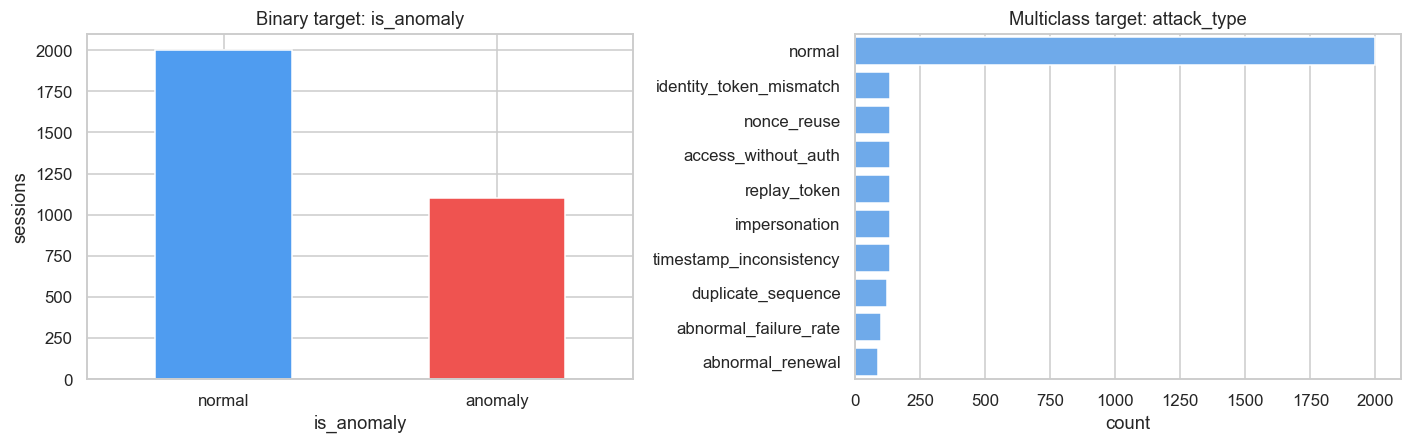

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
(df["is_anomaly"].map({0: "normal", 1: "anomaly"}).value_counts()
   .plot.bar(ax=axes[0], color=["#4f9cf0", "#ef5350"], rot=0))
axes[0].set_title("Binary target: is_anomaly"); axes[0].set_ylabel("sessions")

order = df["attack_type"].value_counts().index
sns.countplot(data=df, y="attack_type", order=order, ax=axes[1], color="#5aa9ff")
axes[1].set_title("Multiclass target: attack_type"); axes[1].set_ylabel("")
plt.tight_layout(); plt.show()

In [5]:
# Missingness
miss = df.isna().mean().sort_values(ascending=False)
print("Columns with any missing values:", int((miss > 0).sum()))
miss[miss > 0].head(15)

Columns with any missing values: 1


payload_hash    0.676129
dtype: float64

### Structural-separability check

An **earlier** version of this dataset leaked the label structurally: attacks
terminated the session at the injection point, so they were much shorter than
normal sessions and length / lifecycle features (`n_events`, `session_duration_s`,
`reached_*`, `visited_states`) separated the classes almost perfectly on their own.

This matters more for a tree than for a linear model: a Decision Tree greedily
picks the single most separating split, so any residual leak would show up
immediately as the **root node**. The generator has since been fixed — attacks run
the full lifecycle, a tunable *stealth* fraction is deliberately indistinguishable
from normal traffic, and durations use a monotonic clock. The boxplots below show
the residual difference is mild; Section 7 checks what the tree actually splits on,
and Section 8 retrains without the structural group entirely.

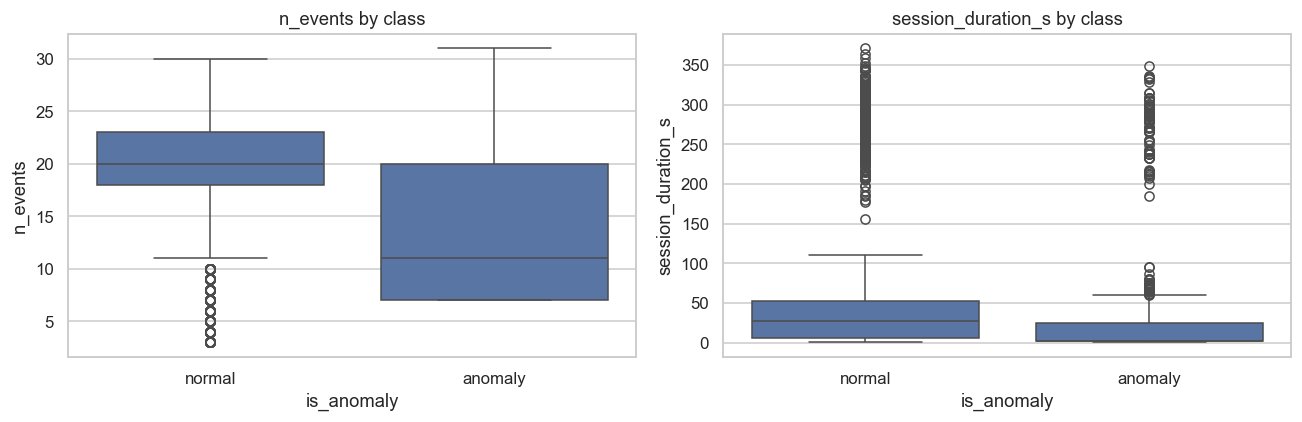

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x="is_anomaly", y="n_events", ax=axes[0])
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["normal", "anomaly"])
axes[0].set_title("n_events by class")
sns.boxplot(data=df, x="is_anomaly", y="session_duration_s", ax=axes[1])
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(["normal", "anomaly"])
axes[1].set_title("session_duration_s by class")
plt.tight_layout(); plt.show()

## 3. Data Cleaning

Identical to the Logistic Regression notebook — this is deliberate, so any score
difference between the two models comes from the learner, not from the features.

* **Identifiers** — UUIDs / IPs / topics with no predictive value and infinite cardinality.
* **Label aliases** — `attack_type`, `attack_phase`, `severity` (and `attacker_class`
  when present) all encode the target and would leak it directly.
* **Constant columns** — zero-variance features carry no information.

Missing values are imputed (`0` for numerics, `"missing"` for categoricals).

In [7]:
TARGET = "is_anomaly"

ID_COLS = ["scenario_id", "session_id", "device_id", "gateway_id",
           "claimed_device_id", "source_ip", "requested_topic",
           "payload_hash", "message_id"]
LABEL_ALIASES = ["attack_type", "attack_phase", "severity", "attacker_class"]

const_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
print("Constant columns dropped (", len(const_cols), "):", const_cols)

drop_cols = sorted((set(ID_COLS) | set(LABEL_ALIASES) | set(const_cols)) & set(df.columns))
X = df.drop(columns=drop_cols + [TARGET])
y = df[TARGET].astype(int)

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()
X[cat_cols] = X[cat_cols].fillna("missing")
X[num_cols] = X[num_cols].fillna(0)

print(f"\nFeatures kept: {X.shape[1]}  ({len(num_cols)} numeric, {len(cat_cols)} categorical)")
print("Categorical columns:", cat_cols)

Constant columns dropped ( 11 ): ['mqtt_version', 'topic_length', 'duplicate_flag', 's1_latency_ms', 'n_gateway_advertisement', 'n_pairing_request', 'n_registration_request', 'n_registration_confirmed', 'n_token_rejected', 'n_token_expired', 'n_timeout']

Features kept: 85  (81 numeric, 4 categorical)
Categorical columns: ['tcp_flags', 'mqtt_msg_type', 'connack_code', 'operation']


C:\Users\lamia\AppData\Local\Temp\ipykernel_21476\3059364113.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns.tolist()


## 4. Preprocessing & Train/Test Split

A tree splits on thresholds *within* one feature at a time, so it is invariant to
monotone rescaling: **no `StandardScaler`** here (unlike the LR notebook). Numeric
columns are passed through untouched, which also keeps the printed rules in
Section 7 in their original physical units (seconds, milliseconds, counts).

Categoricals are one-hot encoded so each level becomes its own binary test.
The split is the same stratified 80/20 with `random_state=42`, so the test rows are
exactly the ones the LR notebook was scored on.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

preprocess = ColumnTransformer([
    ("num", "passthrough", num_cols),                                   # trees need no scaling
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train class balance:", np.bincount(y_train), " Test class balance:", np.bincount(y_test))

Train: (2480, 85)  Test: (620, 85)
Train class balance: [1600  880]  Test class balance: [400 220]


## 5. Model Training — Decision Tree

### 5.1 Baseline: a fully-grown tree (why pruning is mandatory)

Left unconstrained, a tree grows until every leaf is pure. It memorises the
training set — training F1 is a meaningless 1.0 — and the gap to the test score is
the overfitting we then have to control.

In [9]:
dt_full = Pipeline([
    ("pre", preprocess),
    ("dt", DecisionTreeClassifier(random_state=RANDOM_STATE)),
]).fit(X_train, y_train)

tree_full = dt_full.named_steps["dt"]
print(f"Depth: {tree_full.get_depth()}   Leaves: {tree_full.get_n_leaves()}")
print(f"Train F1 (anomaly): {f1_score(y_train, dt_full.predict(X_train)):.4f}")
print(f"Test  F1 (anomaly): {f1_score(y_test,  dt_full.predict(X_test)):.4f}")
print(f"Generalisation gap: {f1_score(y_train, dt_full.predict(X_train)) - f1_score(y_test, dt_full.predict(X_test)):+.4f}")

Depth: 29   Leaves: 100
Train F1 (anomaly): 1.0000
Test  F1 (anomaly): 0.9070
Generalisation gap: +0.0930


### 5.2 Complexity control

Two complementary views, both cross-validated on the **training set only**:

* a **validation curve** over `max_depth` — where does extra depth stop paying?
* a **cost-complexity pruning path** — `ccp_alpha` penalises leaves, collapsing the
  weakest subtrees first. This is the more principled knob: it prunes where the
  data does not support the split rather than at a fixed depth.

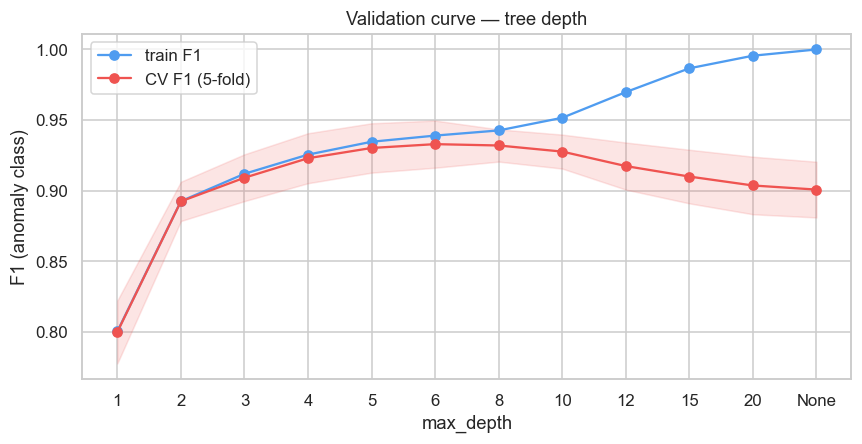

Best max_depth by CV F1: 6  (CV F1 = 0.9329 )


In [10]:
depths = [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20, None]
depth_labels = [d if d is not None else "None" for d in depths]

train_sc, val_sc = validation_curve(
    Pipeline([("pre", preprocess), ("dt", DecisionTreeClassifier(random_state=RANDOM_STATE))]),
    X_train, y_train, param_name="dt__max_depth", param_range=depths,
    cv=CV, scoring="f1", n_jobs=-1)

xs = np.arange(len(depths))
plt.figure(figsize=(8, 4.2))
plt.plot(xs, train_sc.mean(1), "o-", color="#4f9cf0", label="train F1")
plt.plot(xs, val_sc.mean(1),   "o-", color="#ef5350", label="CV F1 (5-fold)")
plt.fill_between(xs, val_sc.mean(1) - val_sc.std(1), val_sc.mean(1) + val_sc.std(1),
                 color="#ef5350", alpha=0.15)
plt.xticks(xs, depth_labels); plt.xlabel("max_depth"); plt.ylabel("F1 (anomaly class)")
plt.title("Validation curve — tree depth"); plt.legend(); plt.tight_layout(); plt.show()

best_depth = depths[int(np.argmax(val_sc.mean(1)))]
print("Best max_depth by CV F1:", best_depth, " (CV F1 =", round(val_sc.mean(1).max(), 4), ")")

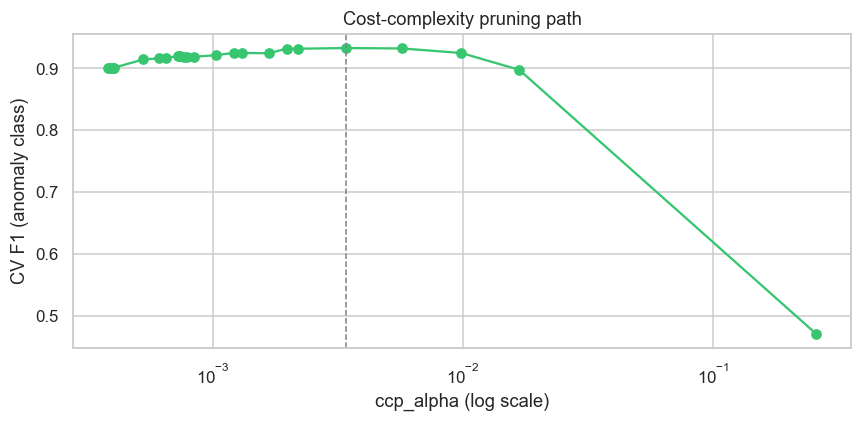

Best ccp_alpha: 0.0034107  (CV F1 = 0.9325)


In [11]:
# Cost-complexity pruning path, computed on the encoded training matrix
enc = ColumnTransformer([
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
]).fit(X_train, y_train)
Xtr_enc = enc.transform(X_train)
feat_names = enc.get_feature_names_out()

path = DecisionTreeClassifier(random_state=RANDOM_STATE).cost_complexity_pruning_path(Xtr_enc, y_train)
alphas = np.unique(path.ccp_alphas[path.ccp_alphas > 0])
alphas = alphas[np.linspace(0, len(alphas) - 1, min(25, len(alphas))).astype(int)]  # subsample the path

scores = [cross_val_score(
             Pipeline([("pre", preprocess),
                       ("dt", DecisionTreeClassifier(ccp_alpha=a, random_state=RANDOM_STATE))]),
             X_train, y_train, cv=CV, scoring="f1", n_jobs=-1).mean()
          for a in alphas]

best_alpha = float(alphas[int(np.argmax(scores))])
plt.figure(figsize=(8, 4))
plt.plot(alphas, scores, "o-", color="#37c66f")
plt.axvline(best_alpha, ls="--", color="grey", lw=1)
plt.xscale("log"); plt.xlabel("ccp_alpha (log scale)"); plt.ylabel("CV F1 (anomaly class)")
plt.title("Cost-complexity pruning path"); plt.tight_layout(); plt.show()

print(f"Best ccp_alpha: {best_alpha:.5g}  (CV F1 = {max(scores):.4f})")

### 5.3 Grid search

Search `criterion` x `max_depth` x `min_samples_leaf` x `ccp_alpha` x `class_weight`,
scored on **anomaly-class F1** (not accuracy — with 35% attacks, accuracy is still
the wrong headline metric) with 5-fold CV on the training set. The test set is
untouched until Section 6.

In [12]:
param_grid = {
    "dt__criterion":        ["gini", "entropy"],
    "dt__max_depth":        [3, 4, 5, 6, 8, 10, None],
    "dt__min_samples_leaf": [1, 5, 10],
    "dt__ccp_alpha":        [0.0, best_alpha],
    "dt__class_weight":     [None, "balanced"],
}

gs = GridSearchCV(
    Pipeline([("pre", preprocess), ("dt", DecisionTreeClassifier(random_state=RANDOM_STATE))]),
    param_grid, scoring="f1", cv=CV, n_jobs=-1, refit=True)
gs.fit(X_train, y_train)

print("Best CV F1 (anomaly):", round(gs.best_score_, 4))
for k, v in gs.best_params_.items():
    print(f"  {k:24s} {v}")

dt_clf = gs.best_estimator_
tree_ = dt_clf.named_steps["dt"]
print(f"\nPruned tree — depth {tree_.get_depth()}, {tree_.get_n_leaves()} leaves "
      f"(vs depth {tree_full.get_depth()}, {tree_full.get_n_leaves()} leaves unpruned)")

Best CV F1 (anomaly): 0.9361
  dt__ccp_alpha            0.0
  dt__class_weight         None
  dt__criterion            entropy
  dt__max_depth            8
  dt__min_samples_leaf     5

Pruned tree — depth 8, 12 leaves (vs depth 29, 100 leaves unpruned)


In [13]:
# Top-10 grid-search configurations
cvres = (pd.DataFrame(gs.cv_results_)
           .sort_values("rank_test_score")
           .loc[:, ["param_dt__criterion", "param_dt__max_depth", "param_dt__min_samples_leaf",
                    "param_dt__ccp_alpha", "param_dt__class_weight",
                    "mean_test_score", "std_test_score"]]
           .head(10)
           .rename(columns=lambda c: c.replace("param_dt__", "")))
cvres.round(4)

,criterion,max_depth,min_samples_leaf,ccp_alpha,class_weight,mean_test_score,std_test_score
34,entropy,8,5,0.0000,NaN,0.9361,0.0180
118,entropy,8,5,0.0034,NaN,0.9361,0.0180
117,entropy,8,1,0.0034,NaN,0.9355,0.0189
33,entropy,8,1,0.0000,NaN,0.9355,0.0189
10,gini,6,5,0.0000,NaN,0.9346,0.0153
13,gini,8,5,0.0000,NaN,0.9336,0.0105
9,gini,6,1,0.0000,NaN,0.9329,0.0167
94,gini,6,5,0.0034,NaN,0.9325,0.0160
103,gini,None,5,0.0034,NaN,0.9325,0.0160
102,gini,None,1,0.0034,NaN,0.9325,0.0160


## 6. Evaluation

Reported on the **anomaly class**, not the weighted average: with 65% normals the
weighted F1 flatters the model and hides exactly the misses that matter
(the deliberately-stealthy attacks).

In [14]:
y_pred  = dt_clf.predict(X_test)
y_proba = dt_clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["normal", "anomaly"], digits=4))
print("Accuracy            :", round(accuracy_score(y_test, y_pred), 4))
print("Precision (anomaly) :", round(precision_score(y_test, y_pred), 4))
print("Recall    (anomaly) :", round(recall_score(y_test, y_pred), 4))
print("F1        (anomaly) :", round(f1_score(y_test, y_pred), 4))
print("F1        (weighted):", round(f1_score(y_test, y_pred, average="weighted"), 4))
print("ROC-AUC             :", round(roc_auc_score(y_test, y_proba), 4))

              precision    recall  f1-score   support

      normal     0.9368    1.0000    0.9674       400
     anomaly     1.0000    0.8773    0.9346       220

    accuracy                         0.9565       620
   macro avg     0.9684    0.9386    0.9510       620
weighted avg     0.9592    0.9565    0.9557       620

Accuracy            : 0.9565
Precision (anomaly) : 1.0
Recall    (anomaly) : 0.8773
F1        (anomaly) : 0.9346
F1        (weighted): 0.9557
ROC-AUC             : 0.9584


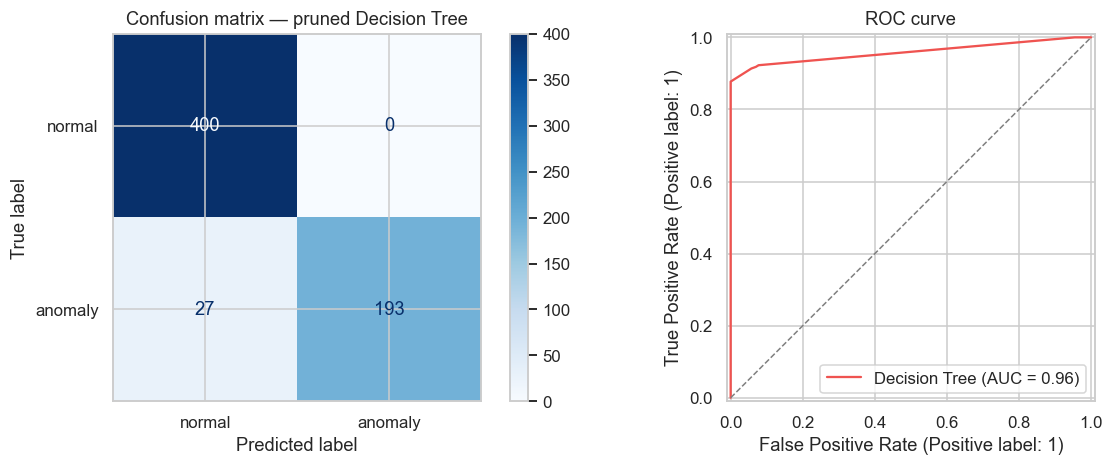

False negatives (missed attacks): 27   <- includes the deliberately stealthy sessions
False positives (benign flagged): 0


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["normal", "anomaly"], cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion matrix — pruned Decision Tree")
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], name="Decision Tree",
                                 curve_kwargs={"color": "#ef5350"})
axes[1].plot([0, 1], [0, 1], "--", color="grey", lw=1)
axes[1].set_title("ROC curve")
plt.tight_layout(); plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"False negatives (missed attacks): {fn}   <- includes the deliberately stealthy sessions")
print(f"False positives (benign flagged): {fp}")

### Did pruning actually help?

The unpruned tree from 5.1 versus the CV-selected one, train and test side by side.
A smaller train-test gap with an equal-or-better test score is the whole point of
pruning: fewer leaves, less memorisation, same detection.

In [16]:
def scores_of(model, label):
    return {
        "model":      label,
        "leaves":     model.named_steps["dt"].get_n_leaves(),
        "depth":      model.named_steps["dt"].get_depth(),
        "train F1":   f1_score(y_train, model.predict(X_train)),
        "test F1":    f1_score(y_test,  model.predict(X_test)),
        "test prec.": precision_score(y_test, model.predict(X_test)),
        "test rec.":  recall_score(y_test,  model.predict(X_test)),
        "test AUC":   roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]),
    }

pd.DataFrame([scores_of(dt_full, "unpruned"), scores_of(dt_clf, "CV-pruned")]).set_index("model").round(4)

,leaves,depth,train F1,test F1,test prec.,test rec.,test AUC
model,,,,,,,
unpruned,100,29,1.0000,0.9070,0.905,0.9091,0.9283
CV-pruned,12,8,0.9373,0.9346,1.000,0.8773,0.9584


## 7. Interpretation — reading the tree

The practical argument for a Decision Tree in intrusion detection: the model *is*
its explanation. An analyst can read why a session was flagged, and the rule can be
transcribed into a gateway policy.

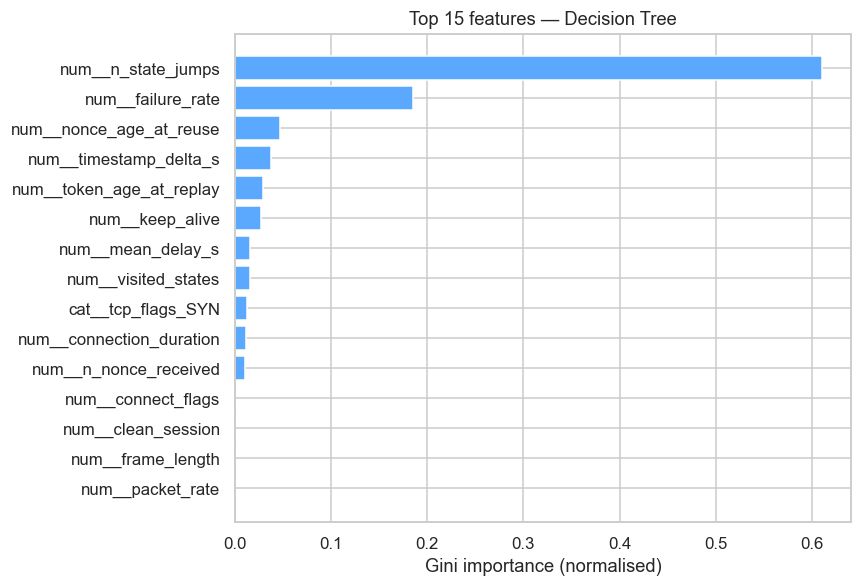

Features actually used by the tree: 11 of 102

Top 10:
num__n_state_jumps          0.6107
num__failure_rate           0.1849
num__nonce_age_at_reuse     0.0466
num__timestamp_delta_s      0.0375
num__token_age_at_replay    0.0289
num__keep_alive             0.0270
num__mean_delay_s           0.0153
num__visited_states         0.0153
cat__tcp_flags_SYN          0.0120
num__connection_duration    0.0118
dtype: float64


In [17]:
names = dt_clf.named_steps["pre"].get_feature_names_out()
imp = (pd.Series(tree_.feature_importances_, index=names)
         .sort_values(ascending=False))
top = imp.head(15)[::-1]

plt.figure(figsize=(8, 5.5))
plt.barh(top.index, top.values, color="#5aa9ff")
plt.xlabel("Gini importance (normalised)")
plt.title("Top 15 features — Decision Tree")
plt.tight_layout(); plt.show()

print("Features actually used by the tree:", int((imp > 0).sum()), "of", len(imp))
print("\nTop 10:")
print(imp.head(10).round(4))

Gini importance credits a feature for the impurity it removes. Reading it next to
the LR coefficients is informative: the linear model spreads weight across many
correlated signals, while the tree concentrates on a handful of decisive tests —
and it says explicitly *at what value* each one becomes decisive. Only ~11 of the
102 encoded features are used at all.

That concentration is also a **diagnostic worth stating plainly**: the tree puts most
of its mass on `n_state_jumps` and `failure_rate`, and `n_state_jumps > 0.5` is the
root split. These are *injection artifacts* — side effects of how an anomalous event
is spliced into the session — rather than authentication evidence an attacker would
have to produce. The linear model uses the same signals but spreads weight across
correlated features, so the dependence is invisible in its coefficient plot; the tree
makes it explicit. Section 8 removes this group entirely and the model still works
(F1 stays above 0.91 on genuine authentication features), so the detection is not
*only* the artifact — but the root split is the honest caveat to raise before
claiming the tree learned authentication semantics.

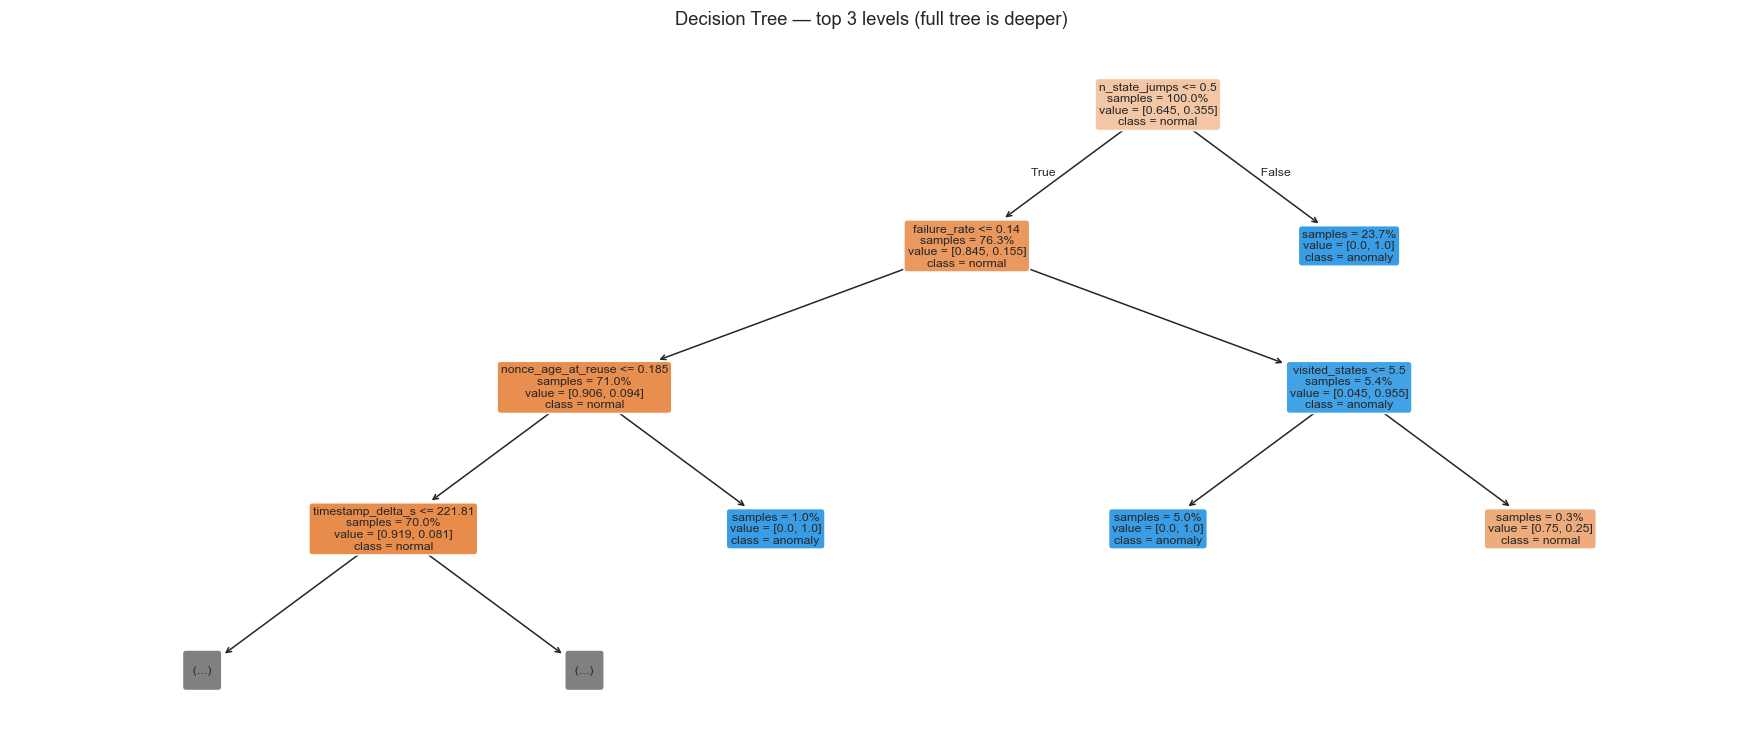

In [18]:
plt.figure(figsize=(16, 7))
plot_tree(tree_, feature_names=[n.replace("num__", "").replace("cat__", "") for n in names],
          class_names=["normal", "anomaly"], filled=True, rounded=True,
          max_depth=3, fontsize=8, impurity=False, proportion=True)
plt.title("Decision Tree — top 3 levels (full tree is deeper)")
plt.tight_layout(); plt.show()

In [19]:
rules = export_text(tree_, max_depth=3, decimals=2,
                    feature_names=[n.replace("num__", "").replace("cat__", "") for n in names])
print("Decision rules (top 3 levels):\n")
print(rules)

Decision rules (top 3 levels):

|--- n_state_jumps <= 0.50
|   |--- failure_rate <= 0.14
|   |   |--- nonce_age_at_reuse <= 0.19
|   |   |   |--- timestamp_delta_s <= 221.81
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- timestamp_delta_s >  221.81
|   |   |   |   |--- class: 1
|   |   |--- nonce_age_at_reuse >  0.19
|   |   |   |--- class: 1
|   |--- failure_rate >  0.14
|   |   |--- visited_states <= 5.50
|   |   |   |--- class: 1
|   |   |--- visited_states >  5.50
|   |   |   |--- class: 0
|--- n_state_jumps >  0.50
|   |--- class: 1



## 8. Robustness check — drop structural features

Same check as Section 7 of the LR notebook: retrain after removing the
session-length / lifecycle group, keeping only the semantic authentication features
(token freshness, nonce reuse, identity mismatch, per-anomaly signals, network /
MQTT context).

If the tree were exploiting a residual structural shortcut, removing that group
would collapse the score. A small drop means the detection rests on genuine
authentication evidence.

In [20]:
STRUCTURAL_LEAK = [
    "n_events", "session_duration_s", "mean_delay_s", "max_delay_s", "min_delay_s",
    "visited_states", "reached_session_open", "reached_access_granted",
    "reached_authenticated", "n_state_jumps", "connection_duration",
] + [c for c in num_cols if c.startswith("n_") and c not in
     ("n_failures", "n_retries", "n_nonce_reuses", "n_token_reuses", "n_renewal_request")]

leak_drop = [c for c in STRUCTURAL_LEAK if c in X.columns]
X2 = X.drop(columns=leak_drop)
num2 = [c for c in num_cols if c in X2.columns]
cat2 = [c for c in cat_cols if c in X2.columns]

Xtr2, Xte2, ytr2, yte2 = train_test_split(
    X2, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
pre2 = ColumnTransformer([
    ("num", "passthrough", num2),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat2),
])
dt2 = Pipeline([("pre", pre2),
                ("dt", DecisionTreeClassifier(
                    **{k.replace("dt__", ""): v for k, v in gs.best_params_.items()},
                    random_state=RANDOM_STATE))]).fit(Xtr2, ytr2)
p2 = dt2.predict(Xte2); pr2 = dt2.predict_proba(Xte2)[:, 1]

print(f"Dropped {len(leak_drop)} structural features.\n")
print("                  full features   structure-free")
print(f"Accuracy       :     {accuracy_score(y_test, y_pred):.4f}          {accuracy_score(yte2, p2):.4f}")
print(f"F1  (anomaly)  :     {f1_score(y_test, y_pred):.4f}          {f1_score(yte2, p2):.4f}")
print(f"Precision      :     {precision_score(y_test, y_pred):.4f}          {precision_score(yte2, p2):.4f}")
print(f"Recall         :     {recall_score(y_test, y_pred):.4f}          {recall_score(yte2, p2):.4f}")
print(f"ROC-AUC        :     {roc_auc_score(y_test, y_proba):.4f}          {roc_auc_score(yte2, pr2):.4f}")

Dropped 33 structural features.

                  full features   structure-free
Accuracy       :     0.9565          0.9403
F1  (anomaly)  :     0.9346          0.9142
Precision      :     1.0000          0.9336
Recall         :     0.8773          0.8955
ROC-AUC        :     0.9584          0.9549


## 9. Multiclass extension — `attack_type`

The same pipeline, now naming the specific attack variant (9 attacks + `normal`).
A tree handles multiclass natively — one model, no one-vs-rest wrapper — which is a
genuine advantage over multinomial LR here.

In [21]:
ymc = df["attack_type"]
Xmc = df.drop(columns=[c for c in (ID_COLS + ["attack_type", "attack_phase",
              "severity", "attacker_class", "is_anomaly"] + const_cols) if c in df.columns])
cmc = Xmc.select_dtypes(include="object").columns.tolist()
nmc = Xmc.select_dtypes(exclude="object").columns.tolist()
Xmc[cmc] = Xmc[cmc].fillna("missing"); Xmc[nmc] = Xmc[nmc].fillna(0)

Xtr, Xte, ytr, yte = train_test_split(
    Xmc, ymc, test_size=0.20, stratify=ymc, random_state=RANDOM_STATE)
pre_mc = ColumnTransformer([
    ("num", "passthrough", nmc),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cmc),
])

gs_mc = GridSearchCV(
    Pipeline([("pre", pre_mc), ("dt", DecisionTreeClassifier(random_state=RANDOM_STATE))]),
    {"dt__criterion": ["gini", "entropy"],
     "dt__max_depth": [6, 8, 10, 12, None],
     "dt__min_samples_leaf": [1, 2, 5],
     "dt__class_weight": [None, "balanced"]},
    scoring="f1_macro", cv=CV, n_jobs=-1).fit(Xtr, ytr)

dt_mc = gs_mc.best_estimator_
pmc = dt_mc.predict(Xte)
proba_mc = dt_mc.predict_proba(Xte)

print("Best params:", {k.replace("dt__", ""): v for k, v in gs_mc.best_params_.items()})
print("Best CV macro-F1:", round(gs_mc.best_score_, 4), "\n")
print(classification_report(yte, pmc, digits=3))
print("Macro one-vs-rest ROC-AUC:",
      round(roc_auc_score(yte, proba_mc, multi_class="ovr", average="macro",
                          labels=dt_mc.classes_), 4))

C:\Users\lamia\AppData\Local\Temp\ipykernel_21476\1846703852.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cmc = Xmc.select_dtypes(include="object").columns.tolist()


Best params: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1}
Best CV macro-F1: 0.9466 

                         precision    recall  f1-score   support

  abnormal_failure_rate      1.000     0.950     0.974        20
       abnormal_renewal      1.000     0.778     0.875        18
    access_without_auth      1.000     1.000     1.000        26
     duplicate_sequence      1.000     0.833     0.909        24
identity_token_mismatch      1.000     0.962     0.980        26
          impersonation      1.000     0.885     0.939        26
            nonce_reuse      1.000     0.815     0.898        27
                 normal      0.920     1.000     0.958       400
           replay_token      1.000     0.667     0.800        27
timestamp_inconsistency      1.000     0.692     0.818        26

               accuracy                          0.944       620
              macro avg      0.992     0.858     0.915       620
           weighted avg

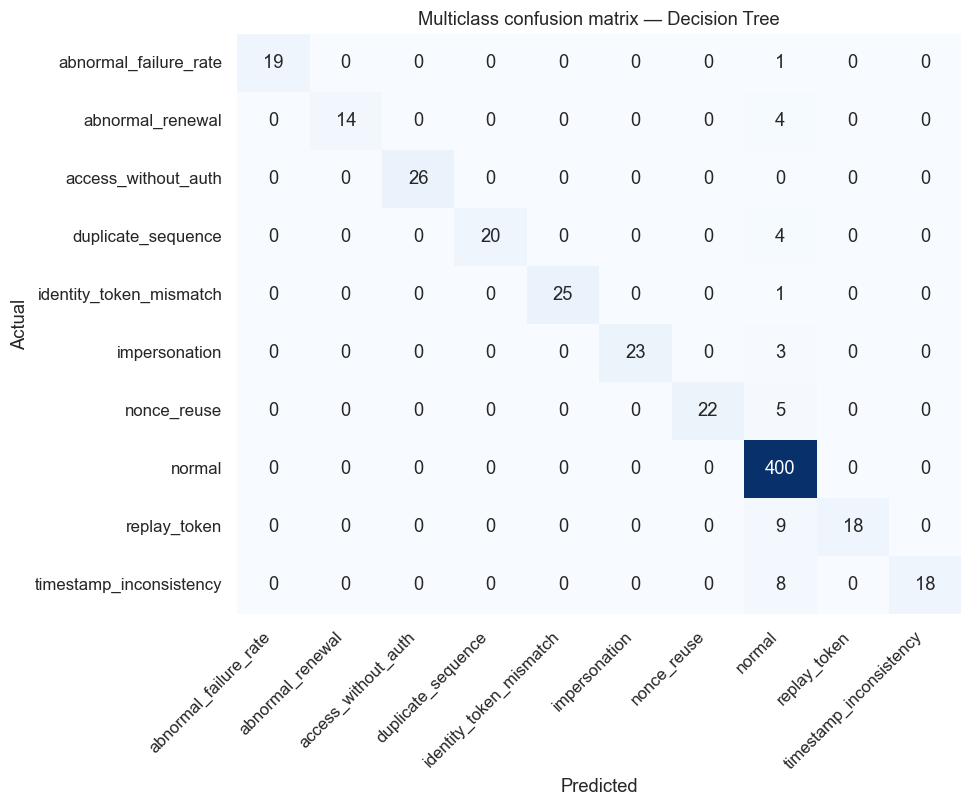

In [22]:
cm = confusion_matrix(yte, pmc, labels=dt_mc.classes_)
plt.figure(figsize=(9, 7.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=dt_mc.classes_, yticklabels=dt_mc.classes_, cbar=False)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Multiclass confusion matrix — Decision Tree")
plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

Per-attack recall is the honest picture of *which* attacks the tree can name. The
loud ones (impersonation, unauthorised access) are recovered nearly perfectly; the
stealthy families (replay, nonce reuse, timestamp) are where the misses live — by
design, since a fraction of those sessions carry no observable trace at all.

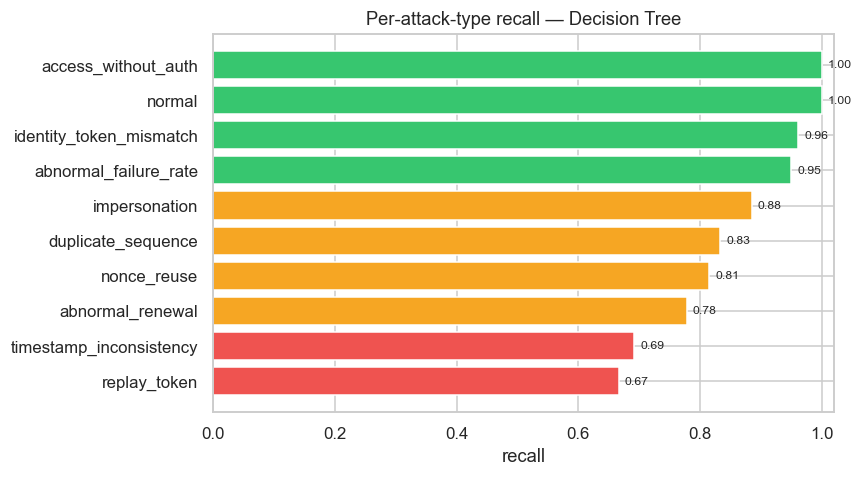

In [23]:
rec = pd.Series({c: recall_score(yte == c, pmc == c) for c in dt_mc.classes_}).sort_values()
plt.figure(figsize=(8, 4.5))
colors = ["#ef5350" if v < 0.7 else "#f6a623" if v < 0.9 else "#37c66f" for v in rec.values]
plt.barh(rec.index, rec.values, color=colors)
plt.xlim(0, 1.02); plt.xlabel("recall")
plt.title("Per-attack-type recall — Decision Tree")
for i, v in enumerate(rec.values):
    plt.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

## 10. Decision Tree vs Logistic Regression

Both models are refit here on the **same split** so the comparison is apples to
apples (the LR configuration is the baseline from its own notebook: standardised
numerics, one-hot categoricals).

,accuracy,precision,recall,F1,ROC-AUC
model,,,,,
Logistic Regression,0.9516,0.9612,0.9000,0.9296,0.9734
Decision Tree (pruned),0.9565,1.0000,0.8773,0.9346,0.9584


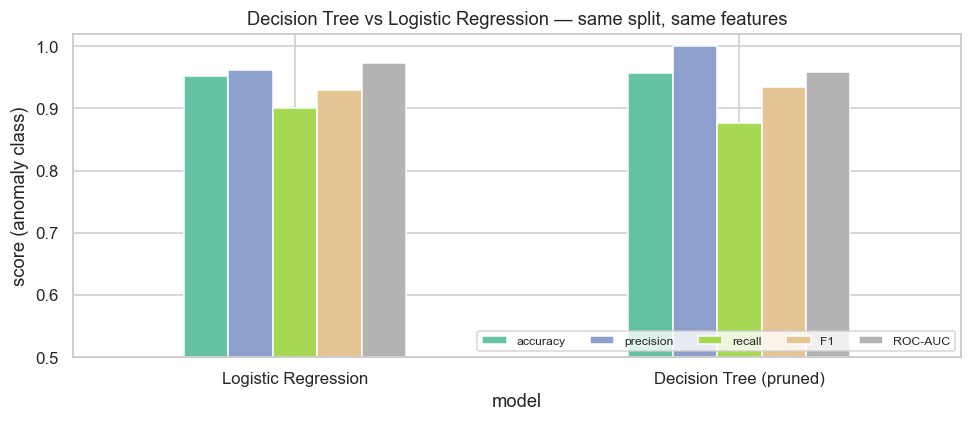

In [24]:
lr_ref = Pipeline([
    ("pre", ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)])),
    ("lr", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
]).fit(X_train, y_train)

def row(model, label):
    p = model.predict(X_test); pr = model.predict_proba(X_test)[:, 1]
    return {"model": label,
            "accuracy":  accuracy_score(y_test, p),
            "precision": precision_score(y_test, p),
            "recall":    recall_score(y_test, p),
            "F1":        f1_score(y_test, p),
            "ROC-AUC":   roc_auc_score(y_test, pr)}

comparison = pd.DataFrame([row(lr_ref, "Logistic Regression"),
                           row(dt_clf, "Decision Tree (pruned)")]).set_index("model")
display(comparison.round(4))

ax = comparison.plot.bar(figsize=(9, 4), rot=0, colormap="Set2")
ax.set_ylim(0.5, 1.02); ax.set_ylabel("score (anomaly class)")
ax.set_title("Decision Tree vs Logistic Regression — same split, same features")
ax.legend(loc="lower right", ncol=5, fontsize=8)
plt.tight_layout(); plt.show()

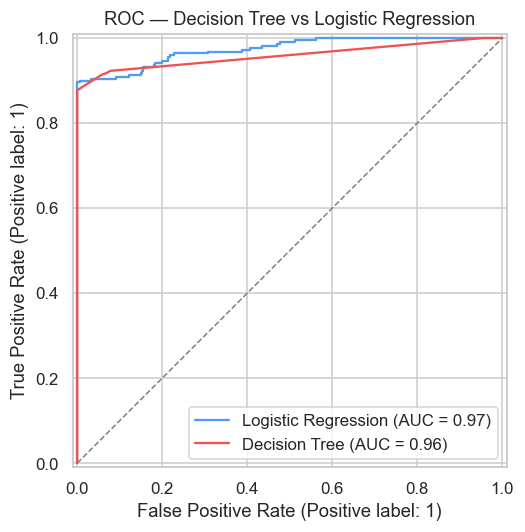

In [25]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(lr_ref, X_test, y_test, ax=ax, name="Logistic Regression",
                               curve_kwargs={"color": "#4f9cf0"})
RocCurveDisplay.from_estimator(dt_clf, X_test, y_test, ax=ax, name="Decision Tree",
                               curve_kwargs={"color": "#ef5350"})
ax.plot([0, 1], [0, 1], "--", color="grey", lw=1)
ax.set_title("ROC — Decision Tree vs Logistic Regression")
plt.tight_layout(); plt.show()

A tree's ROC curve is *coarse*: probabilities come from leaf class-frequencies, so
there are only as many distinct scores as leaves, and the curve is a few straight
segments. That is why a tree's ROC-AUC can trail its F1 — the ranking is
low-resolution even when the hard decisions are right. A Random Forest fixes exactly
this by averaging many trees into a smooth score.

## 11. Summary

* **Pipeline:** load -> EDA -> clean (drop identifiers, label aliases, constant columns)
  -> one-hot categoricals, **no scaling** -> stratified 80/20 split -> Decision Tree
  tuned by 5-fold CV on anomaly-class F1. Cleaning and split are identical to the
  Logistic Regression notebook, so the two are directly comparable.
* **Complexity control:** the fully-grown tree hits training F1 = 1.0 and memorises
  the data. A depth validation curve and a cost-complexity pruning path both locate a
  much smaller tree that matches or beats it on held-out data — reported in 5.3/6.
* **Interpretability:** Section 7 prints the decision rules the model actually uses,
  in physical units. That is the tree's distinctive contribution here: an analyst can
  read the flagging logic and turn it into a gateway policy, which the LR coefficient
  vector does not give as directly.
* **Realism:** the dataset no longer leaks the label structurally (attacks run the
  full lifecycle; a stealth fraction is deliberately indistinguishable from normal
  traffic, plus benign detector triggers). Section 8 confirms the tree does not lean
  on structural features, and the residual false negatives are the stealthy attacks
  no model can recover.
* **Limitation:** a single tree gives step-function probabilities and is
  high-variance — small data changes reshuffle the splits. **Random Forest** is the
  next notebook: it averages many such trees, smoothing both the variance and the
  ROC curve, at the cost of the readable rules recovered here.